In [79]:
## Data Loading


In [80]:
import pandas as pd

df = pd.read_excel("shipment_dataset_10000 -1.xlsx")


In [81]:
df.head()
df.info()
df.isnull().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                10000 non-null  int64         
 1   supplier_id             10000 non-null  int64         
 2   supplier_rating         10000 non-null  float64       
 3   supplier_lead_time      10000 non-null  int64         
 4   order_date              10000 non-null  datetime64[ns]
 5   promised_delivery_date  10000 non-null  datetime64[ns]
 6   actual_delivery_date    10000 non-null  datetime64[ns]
 7   shipment_mode           10000 non-null  object        
 8   shipping_distance_km    10000 non-null  int64         
 9   order_quantity          10000 non-null  int64         
 10  unit_price              10000 non-null  float64       
 11  total_order_value       10000 non-null  float64       
 12  weather_condition       10000 non-null  object 

np.int64(0)

In [82]:
import numpy as np

df_anom = df.copy()

# 1. Null / missing values
cols_for_nulls = ["supplier_rating", "shipment_mode", "region"]
for col in cols_for_nulls:
    idx = np.random.choice(df_anom.index, size=300, replace=False)
    df_anom.loc[idx, col] = np.nan

# 2. Duplicate rows
duplicate_idx = np.random.choice(df_anom.index, size=200, replace=False)
df_anom = pd.concat([df_anom, df_anom.loc[duplicate_idx]], ignore_index=True)

# 3. Datatype mismatch (store numeric as string and vice versa)
df_anom["shipping_distance_km"] = df_anom["shipping_distance_km"].astype(str)
df_anom["order_quantity"] = df_anom["order_quantity"].astype(str)

# 4. Outliers (very large/unrealistic values)
idx_out_dist = np.random.choice(df_anom.index, size=50, replace=False)
df_anom.loc[idx_out_dist, "shipping_distance_km"] = "99999"

idx_out_price = np.random.choice(df_anom.index, size=50, replace=False)
df_anom.loc[idx_out_price, "unit_price"] = df_anom.loc[idx_out_price, "unit_price"] * 100

# 5. Logical errors
# 5a. Wrong country/region names (introduce typos)
idx_region_err = np.random.choice(df_anom.index, size=80, replace=False)
df_anom.loc[idx_region_err, "region"] = np.random.choice(
    ["Eest", "Soth", "Cntral", "Wesst"], size=80
)

# 5b. Shipment date before order date (swap for some rows)
idx_date_err = np.random.choice(df_anom.index, size=80, replace=False)
df_anom.loc[idx_date_err, ["order_date", "actual_delivery_date"]] = \
df_anom.loc[idx_date_err, ["actual_delivery_date", "order_date"]].values


In [83]:
df_anom.to_excel("shipment_dataset_10000_anomalies.xlsx", index=False)


In [84]:
import pandas as pd
import numpy as np

def load_data(path):
    df = pd.read_excel(path)
    return df

def basic_checks(df):
    print(df.info())
    print(df.isnull().sum())
    print("Duplicates:", df.duplicated().sum())


In [85]:
def remove_duplicates(df):
    df = df.drop_duplicates().reset_index(drop=True)
    return df


In [86]:
def fix_dtypes(df):
    # Convert distance and quantity back to numeric
    df["shipping_distance_km"] = pd.to_numeric(df["shipping_distance_km"], errors="coerce")
    df["order_quantity"] = pd.to_numeric(df["order_quantity"], errors="coerce")

    # Ensure dates are datetime
    date_cols = ["order_date", "promised_delivery_date", "actual_delivery_date"]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")

    return df


In [87]:
def handle_missing_values(df):
    # Numeric
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    # Categorical
    cat_cols = df.select_dtypes(include=["object"]).columns
    for col in cat_cols:
        mode_val = df[col].mode(dropna=True)
        if not mode_val.empty:
            df[col] = df[col].fillna(mode_val.iloc[0])

    return df


In [88]:
def cap_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = np.where(df[col] < lower, lower,
                           np.where(df[col] > upper, upper, df[col]))
    return df


In [89]:
numeric_outlier_cols = ["shipping_distance_km", "unit_price",
                        "order_quantity", "total_order_value"]
df = cap_outliers_iqr(df, numeric_outlier_cols)


In [90]:
numeric_outlier_cols = ["shipping_distance_km", "unit_price",
                        "order_quantity", "total_order_value"]
df = cap_outliers_iqr(df, numeric_outlier_cols)


In [91]:
def fix_date_inconsistencies(df):
    mask_bad = df["actual_delivery_date"] < df["order_date"]
    # Simple fix: swap for those
    df.loc[mask_bad, ["order_date", "actual_delivery_date"]] = \
        df.loc[mask_bad, ["actual_delivery_date", "order_date"]].values

    # Optionally, drop remaining impossible rows
    mask_impossible = df["promised_delivery_date"] < df["order_date"]
    df = df[~mask_impossible].reset_index(drop=True)
    return df


In [92]:
import pandas as pd
import numpy as np

def load_data(path):
    return pd.read_excel(path)

def basic_checks(df):
    print(df.info())
    print(df.isnull().sum())
    print("Duplicates:", df.duplicated().sum())

def remove_duplicates(df):
    return df.drop_duplicates().reset_index(drop=True)

def fix_dtypes(df):
    df["shipping_distance_km"] = pd.to_numeric(df["shipping_distance_km"], errors="coerce")
    df["order_quantity"] = pd.to_numeric(df["order_quantity"], errors="coerce")

    date_cols = ["order_date", "promised_delivery_date", "actual_delivery_date"]
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")
    return df

def handle_missing_values(df):
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    for col in num_cols:
        df[col] = df[col].fillna(df[col].median())

    cat_cols = df.select_dtypes(include=["object"]).columns
    for col in cat_cols:
        mode_val = df[col].mode(dropna=True)
        if not mode_val.empty:
            df[col] = df[col].fillna(mode_val.iloc[0])
    return df

def cap_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df[col] = np.where(df[col] < lower, lower,
                           np.where(df[col] > upper, upper, df[col]))
    return df

def fix_region_values(df):
    mapping = {
        "Eest": "East", "EAST": "East",
        "Soth": "South", "SOUTH": "South",
        "Cntral": "Central", "CENTRAL": "Central",
        "Wesst": "West", "WEST": "West"
    }
    df["region"] = df["region"].replace(mapping)
    return df

def fix_date_inconsistencies(df):
    mask_bad = df["actual_delivery_date"] < df["order_date"]
    df.loc[mask_bad, ["order_date", "actual_delivery_date"]] = \
        df.loc[mask_bad, ["actual_delivery_date", "order_date"]].values

    mask_impossible = df["promised_delivery_date"] < df["order_date"]
    df = df[~mask_impossible].reset_index(drop=True)
    return df

def clean_pipeline(input_path, output_path):
    df = load_data(input_path)
    basic_checks(df)

    df = remove_duplicates(df)
    df = fix_dtypes(df)
    df = handle_missing_values(df)
    df = cap_outliers_iqr(df, ["shipping_distance_km", "unit_price",
                               "order_quantity", "total_order_value"])
    df = fix_region_values(df)
    df = fix_date_inconsistencies(df)

    df.to_excel(output_path, index=False)
    print("Cleaned file saved to:", output_path)


In [93]:
clean_pipeline("shipment_dataset_10000_anomalies.xlsx",
               "shipment_dataset_10000_cleaned.xlsx")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                10200 non-null  int64         
 1   supplier_id             10200 non-null  int64         
 2   supplier_rating         9899 non-null   float64       
 3   supplier_lead_time      10200 non-null  int64         
 4   order_date              10200 non-null  datetime64[ns]
 5   promised_delivery_date  10200 non-null  datetime64[ns]
 6   actual_delivery_date    10200 non-null  datetime64[ns]
 7   shipment_mode           9890 non-null   object        
 8   shipping_distance_km    10200 non-null  int64         
 9   order_quantity          10200 non-null  int64         
 10  unit_price              10200 non-null  float64       
 11  total_order_value       10200 non-null  float64       
 12  weather_condition       10200 non-null  object

In [94]:
import pandas as pd, numpy as np
import seaborn as sns, matplotlib.pyplot as plt
%matplotlib inline


In [95]:
df = pd.read_excel("shipment_dataset_10000_cleaned.xlsx")
df.shape, df.head(), df.info(), df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10010 entries, 0 to 10009
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                10010 non-null  int64         
 1   supplier_id             10010 non-null  int64         
 2   supplier_rating         10010 non-null  float64       
 3   supplier_lead_time      10010 non-null  int64         
 4   order_date              10010 non-null  datetime64[ns]
 5   promised_delivery_date  10010 non-null  datetime64[ns]
 6   actual_delivery_date    10010 non-null  datetime64[ns]
 7   shipment_mode           10010 non-null  object        
 8   shipping_distance_km    10010 non-null  int64         
 9   order_quantity          10010 non-null  int64         
 10  unit_price              10010 non-null  float64       
 11  total_order_value       10010 non-null  float64       
 12  weather_condition       10010 non-null  object

((10010, 19),
    order_id  supplier_id  supplier_rating  supplier_lead_time order_date  \
 0         1         5322              3.4                  10 2024-05-15   
 1         2         3932              4.3                  10 2024-11-12   
 2         3         8966              3.2                   5 2024-08-28   
 3         4         9832              3.9                   7 2024-08-12   
 4         5         2126              3.2                   8 2024-07-07   
 
   promised_delivery_date actual_delivery_date shipment_mode  \
 0             2024-05-25           2024-05-29           Sea   
 1             2024-11-22           2024-11-27           Sea   
 2             2024-09-02           2024-09-02           Sea   
 3             2024-08-19           2024-08-19           Air   
 4             2024-07-15           2024-07-18           Sea   
 
    shipping_distance_km  order_quantity  unit_price  total_order_value  \
 0                    51              48     2153.91         

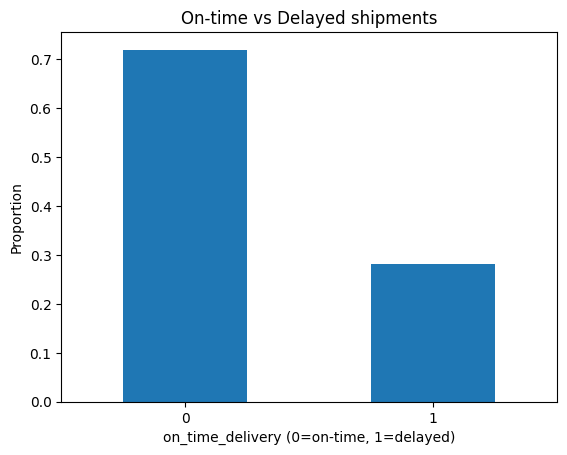

In [96]:
df["on_time_delivery"].value_counts(normalize=True).plot(
    kind="bar", rot=0
)
plt.title("On-time vs Delayed shipments")
plt.xlabel("on_time_delivery (0=on-time, 1=delayed)")
plt.ylabel("Proportion")
plt.show()


In [97]:
df["on_time_delivery"].value_counts(), \
df["on_time_delivery"].value_counts(normalize=True)*100


(on_time_delivery
 0    7201
 1    2809
 Name: count, dtype: int64,
 on_time_delivery
 0    71.938062
 1    28.061938
 Name: proportion, dtype: float64)

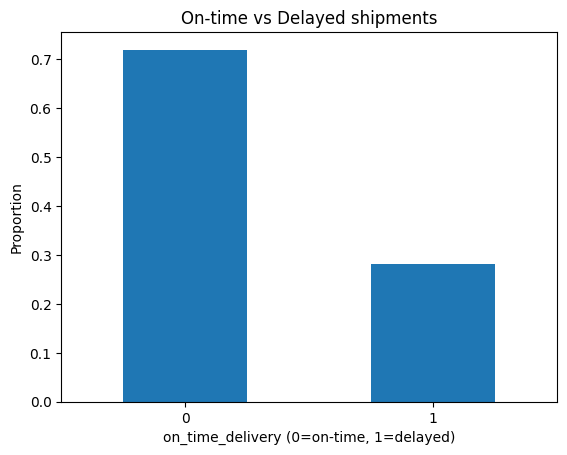

In [98]:
df["on_time_delivery"].value_counts(normalize=True).plot(
    kind="bar", rot=0
)
plt.title("On-time vs Delayed shipments")
plt.xlabel("on_time_delivery (0=on-time, 1=delayed)")
plt.ylabel("Proportion")
plt.show()


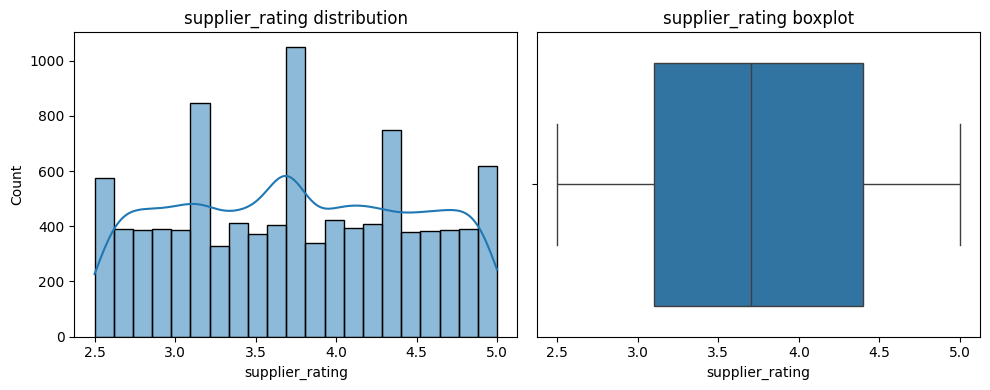

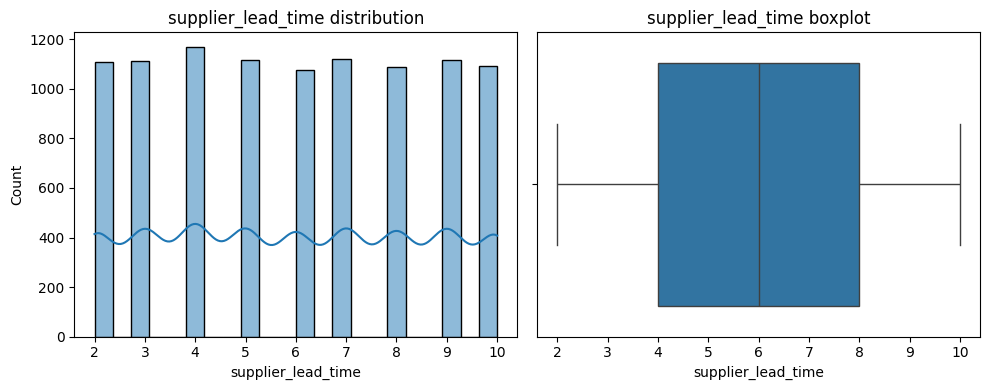

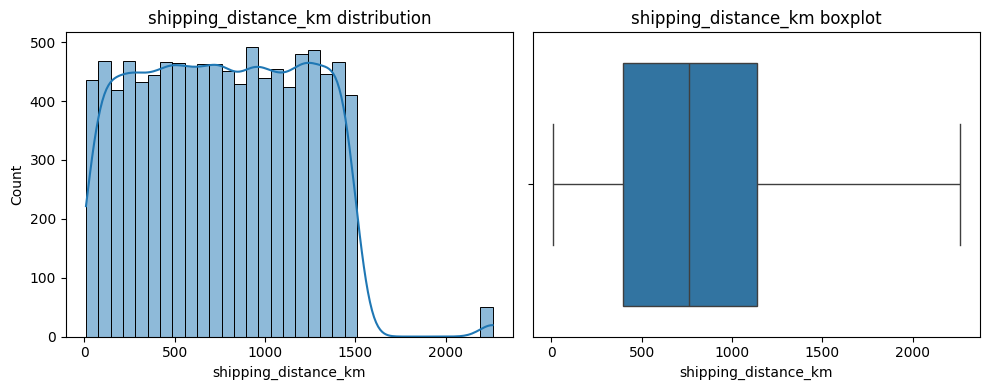

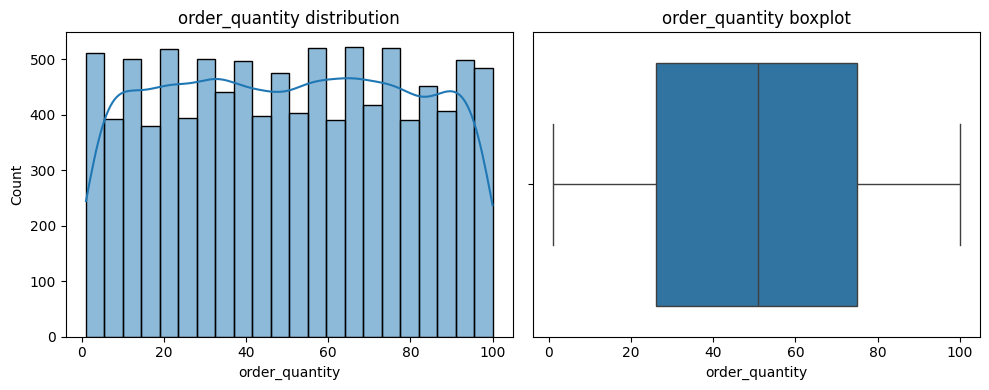

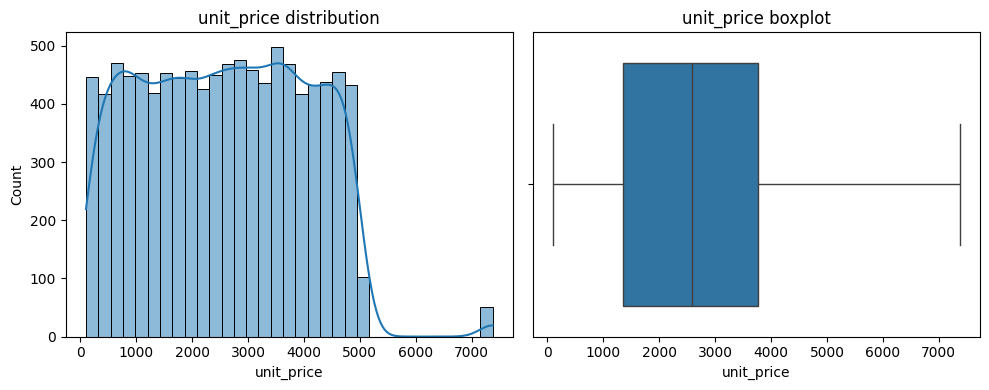

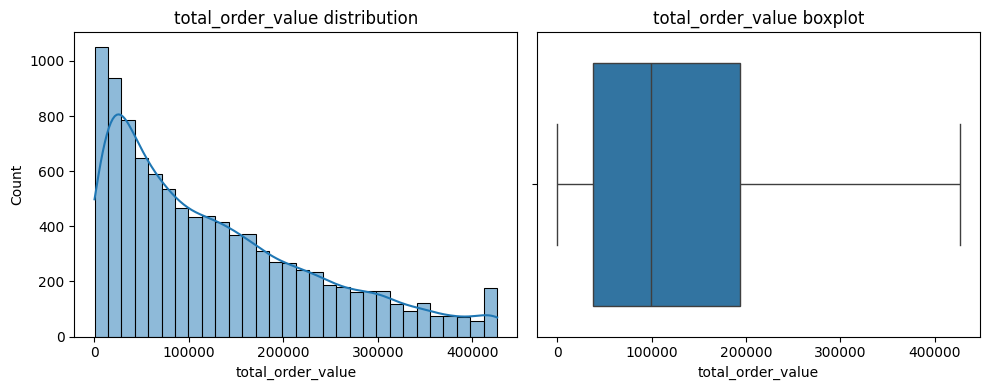

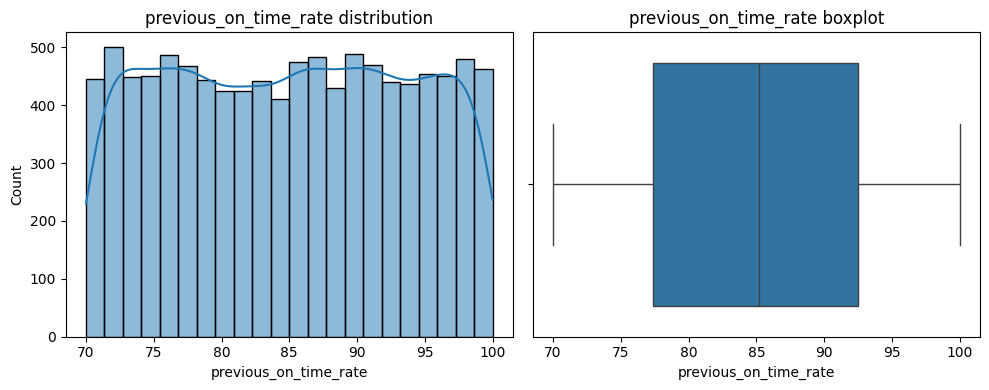

In [99]:
num_cols = ["supplier_rating", "supplier_lead_time",
            "shipping_distance_km", "order_quantity",
            "unit_price", "total_order_value",
            "previous_on_time_rate"]

for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f"{col} distribution")
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"{col} boxplot")
    plt.tight_layout()
    plt.show()


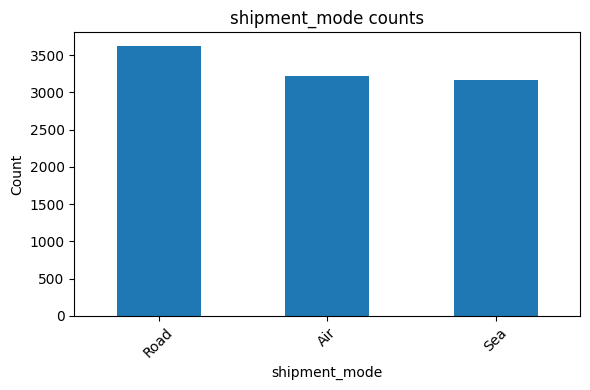

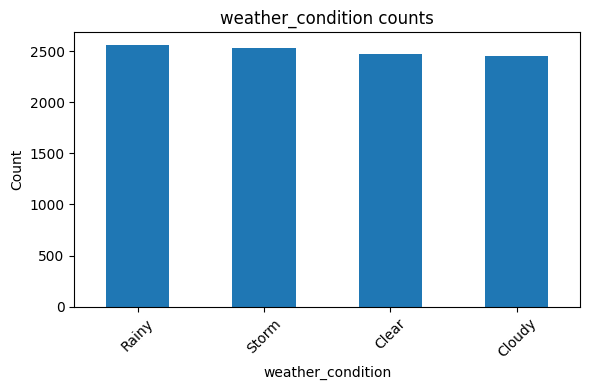

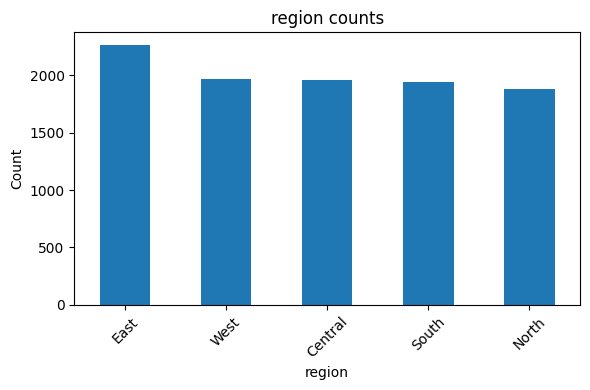

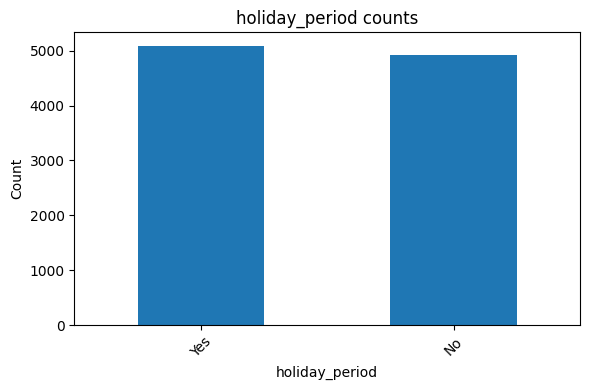

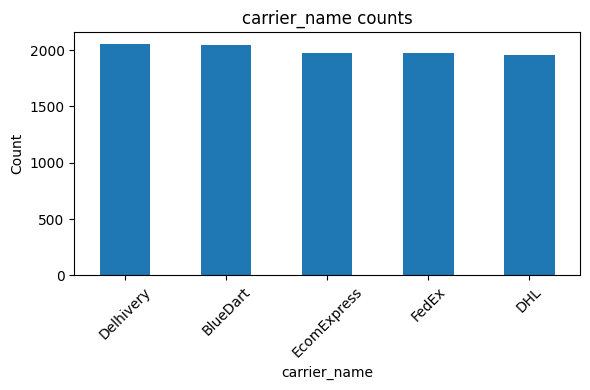

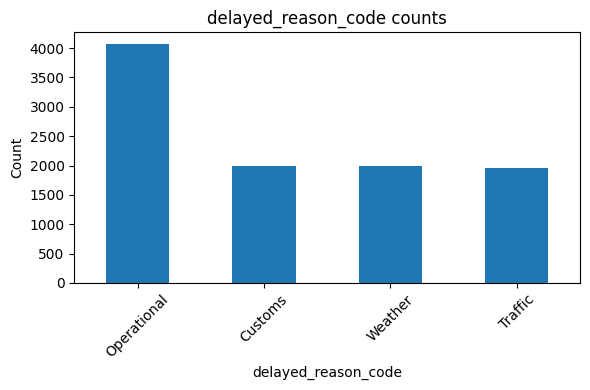

In [100]:
cat_cols = ["shipment_mode", "weather_condition",
            "region", "holiday_period", "carrier_name",
            "delayed_reason_code"]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"{col} counts")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


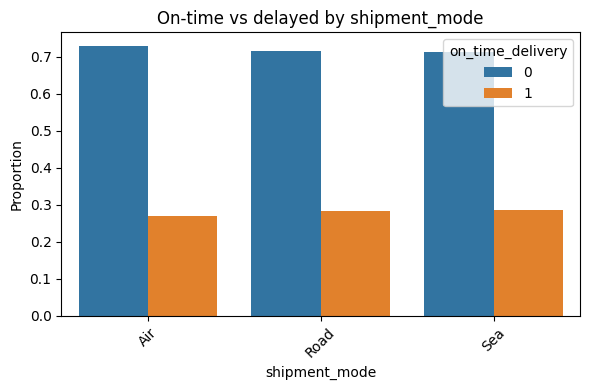

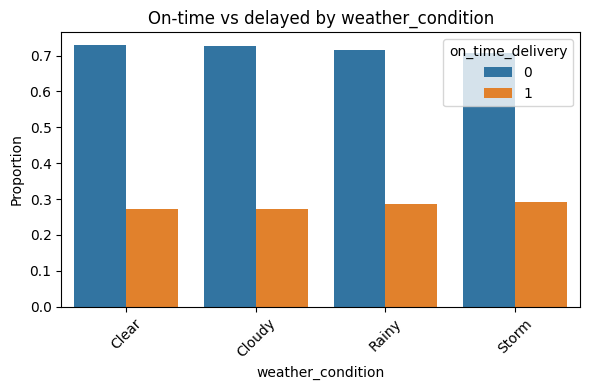

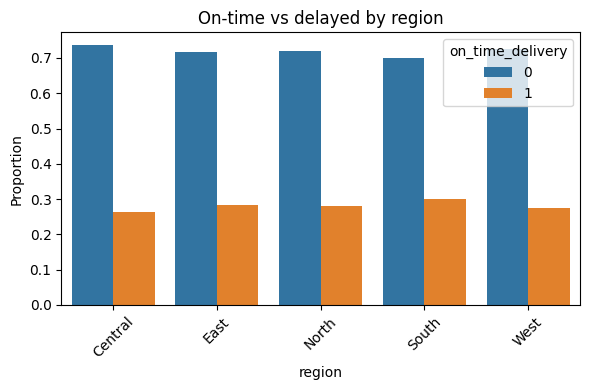

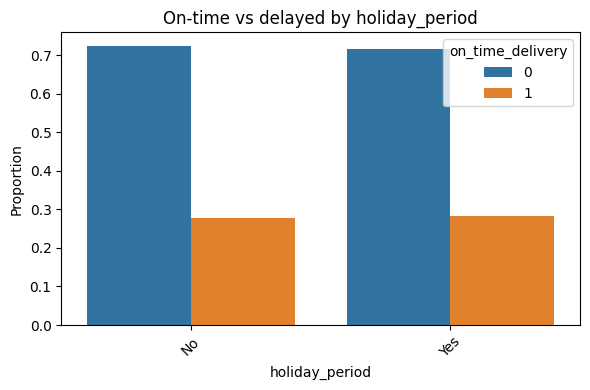

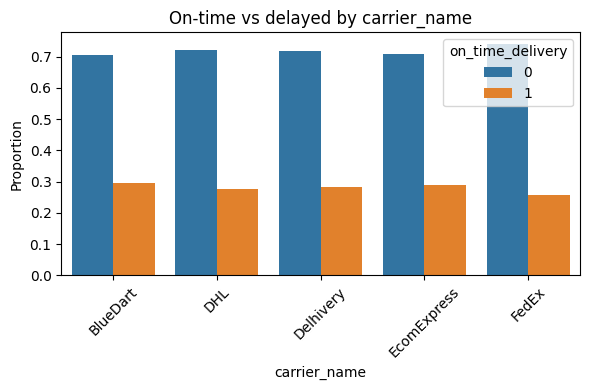

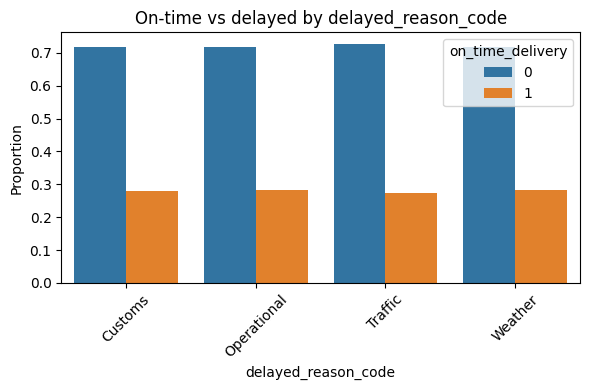

In [101]:
def target_rate_by_cat(col):
    temp = (df.groupby(col)["on_time_delivery"]
              .value_counts(normalize=True)
              .rename("prop")
              .reset_index())
    plt.figure(figsize=(6,4))
    sns.barplot(data=temp, x=col, y="prop",
                hue="on_time_delivery")
    plt.title(f"On-time vs delayed by {col}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    target_rate_by_cat(col)


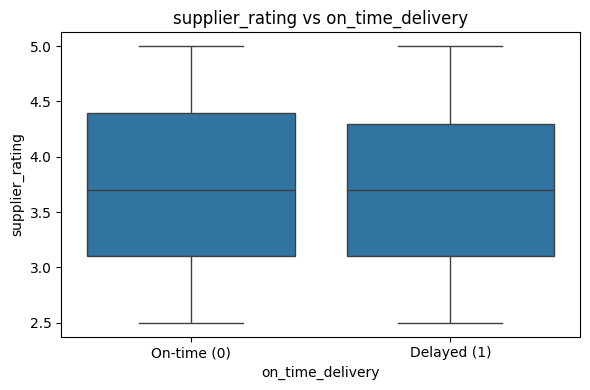

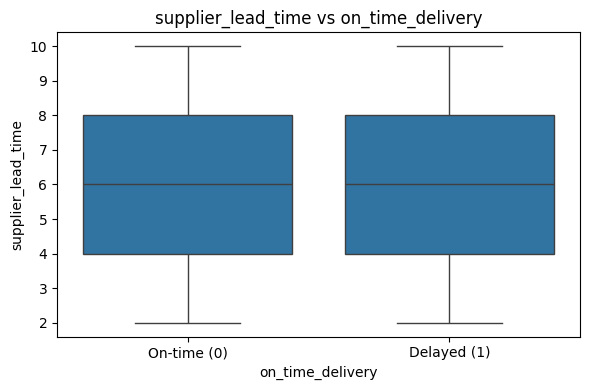

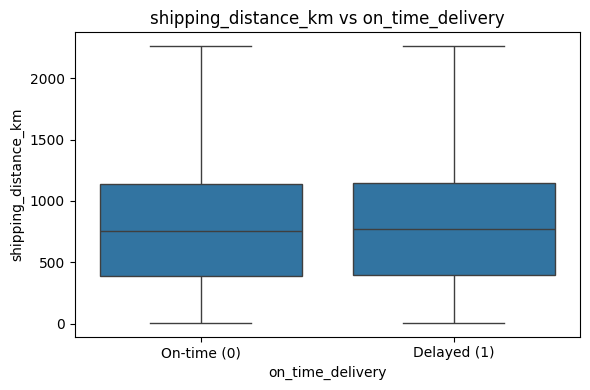

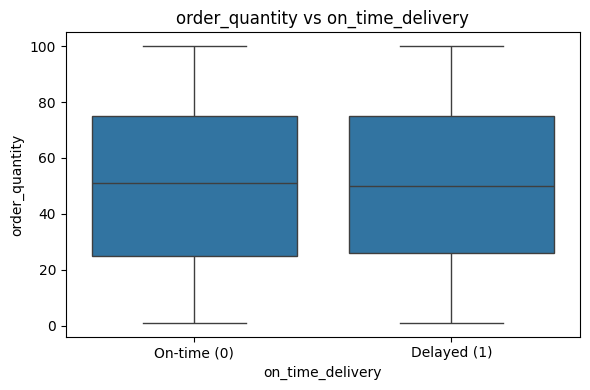

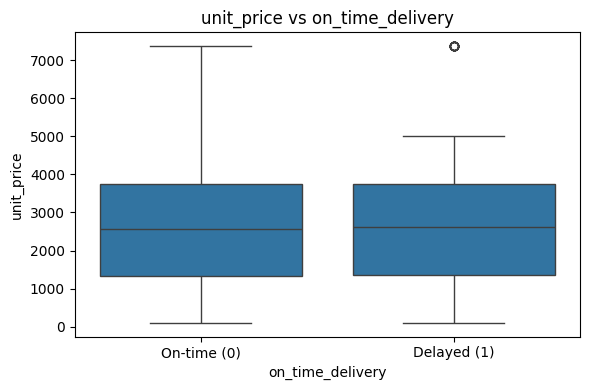

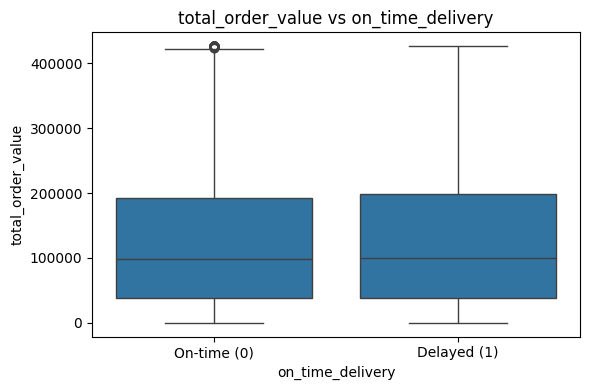

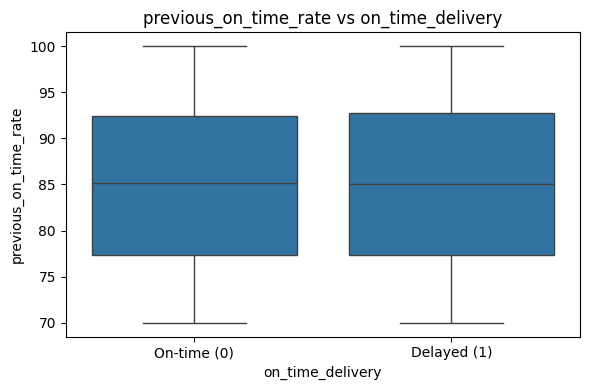

In [102]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="on_time_delivery", y=col)
    plt.title(f"{col} vs on_time_delivery")
    plt.xticks([0,1], ["On-time (0)", "Delayed (1)"])
    plt.tight_layout()
    plt.show()


In [103]:
df.groupby("on_time_delivery")[num_cols].mean()


,supplier_rating,supplier_lead_time,shipping_distance_km,order_quantity,unit_price,total_order_value,previous_on_time_rate
on_time_delivery,,,,,,,
0,3.759728,5.957506,767.097209,50.338286,2571.289172,127701.052121,84.976073
1,3.722570,6.034532,771.326451,50.368815,2592.072360,129168.337179,85.077109


In [104]:
df["order_month"] = df["order_date"].dt.month
df["order_dow"] = df["order_date"].dt.dayofweek  # 0=Mon
df["promised_lead_days"] = (df["promised_delivery_date"] - df["order_date"]).dt.days
df["actual_lead_days"] = (df["actual_delivery_date"] - df["order_date"]).dt.days
df["delay_days"] = (df["actual_delivery_date"] - df["promised_delivery_date"]).dt.days


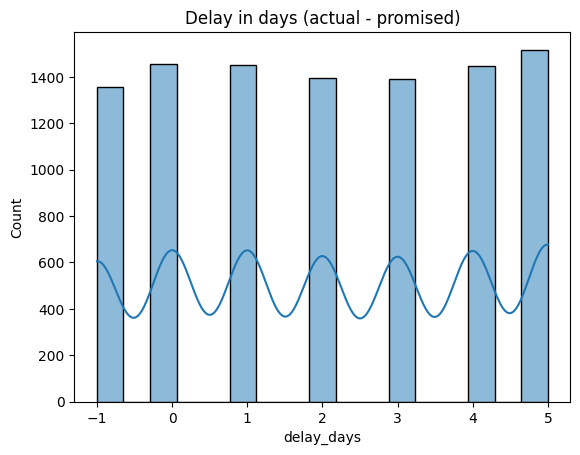

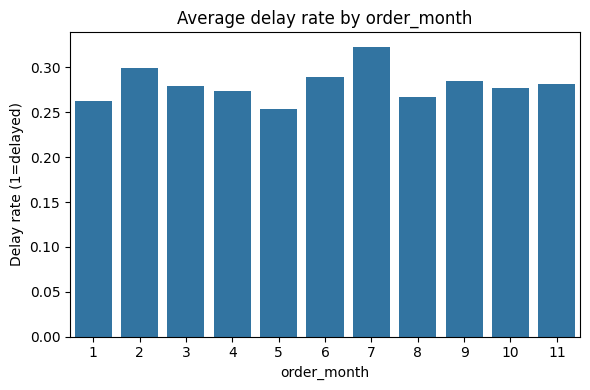

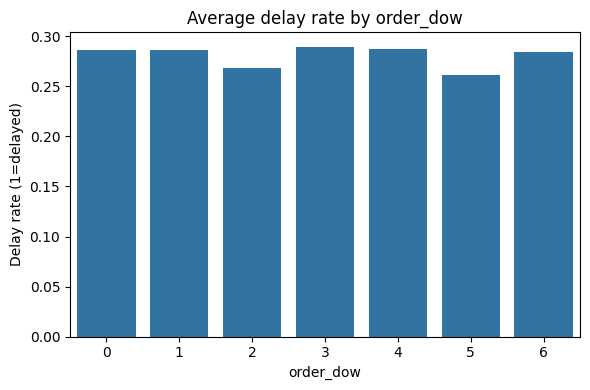

In [105]:
sns.histplot(df["delay_days"], kde=True)
plt.title("Delay in days (actual - promised)")
plt.show()

for col in ["order_month", "order_dow"]:
    temp = (df.groupby(col)["on_time_delivery"]
              .mean()
              .reset_index())
    plt.figure(figsize=(6,4))
    sns.barplot(data=temp, x=col, y="on_time_delivery")
    plt.title(f"Average delay rate by {col}")
    plt.ylabel("Delay rate (1=delayed)")
    plt.tight_layout()
    plt.show()


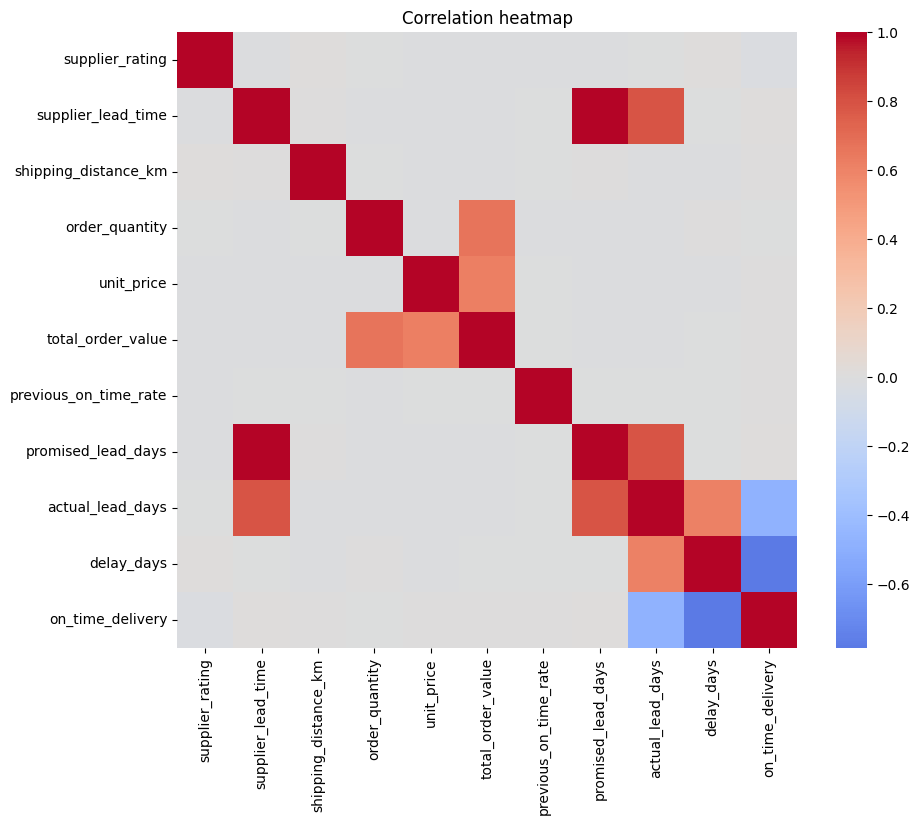

In [106]:
num_for_corr = ["supplier_rating", "supplier_lead_time",
                "shipping_distance_km", "order_quantity",
                "unit_price", "total_order_value",
                "previous_on_time_rate",
                "promised_lead_days", "actual_lead_days",
                "delay_days", "on_time_delivery"]

corr = df[num_for_corr].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()


In [107]:
# if you used clean_pipeline and want df_clean
df_clean = pd.read_excel("shipment_dataset_10000_cleaned.xlsx")  # or use df from your pipeline

df_clean.info()
df_clean.isnull().sum()
df_clean["on_time_delivery"].value_counts(normalize=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10010 entries, 0 to 10009
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                10010 non-null  int64         
 1   supplier_id             10010 non-null  int64         
 2   supplier_rating         10010 non-null  float64       
 3   supplier_lead_time      10010 non-null  int64         
 4   order_date              10010 non-null  datetime64[ns]
 5   promised_delivery_date  10010 non-null  datetime64[ns]
 6   actual_delivery_date    10010 non-null  datetime64[ns]
 7   shipment_mode           10010 non-null  object        
 8   shipping_distance_km    10010 non-null  int64         
 9   order_quantity          10010 non-null  int64         
 10  unit_price              10010 non-null  float64       
 11  total_order_value       10010 non-null  float64       
 12  weather_condition       10010 non-null  object

on_time_delivery
0    0.719381
1    0.280619
Name: proportion, dtype: float64

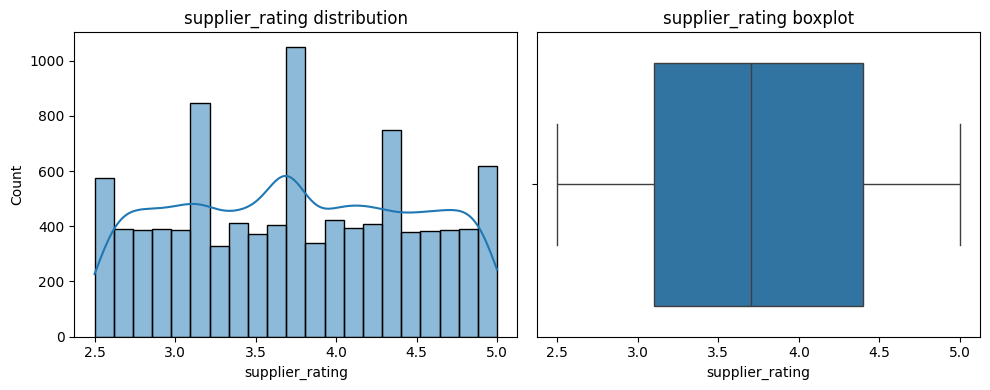

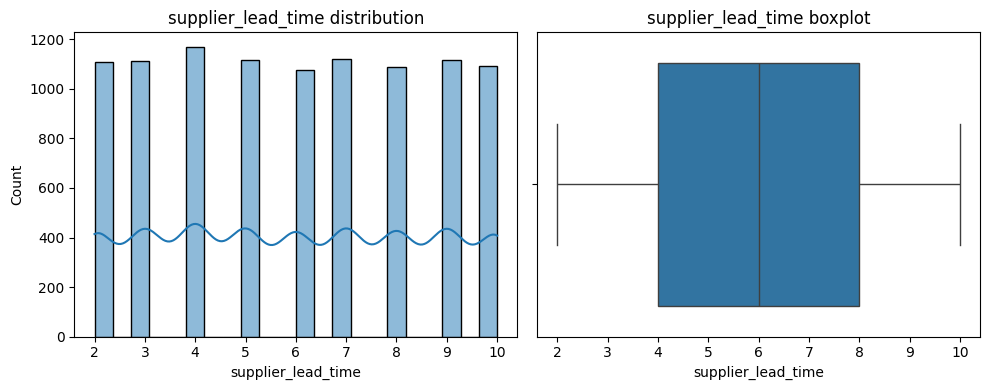

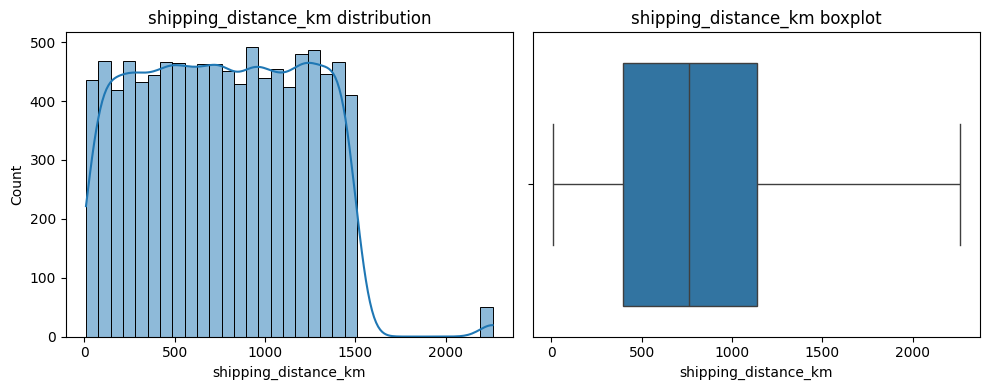

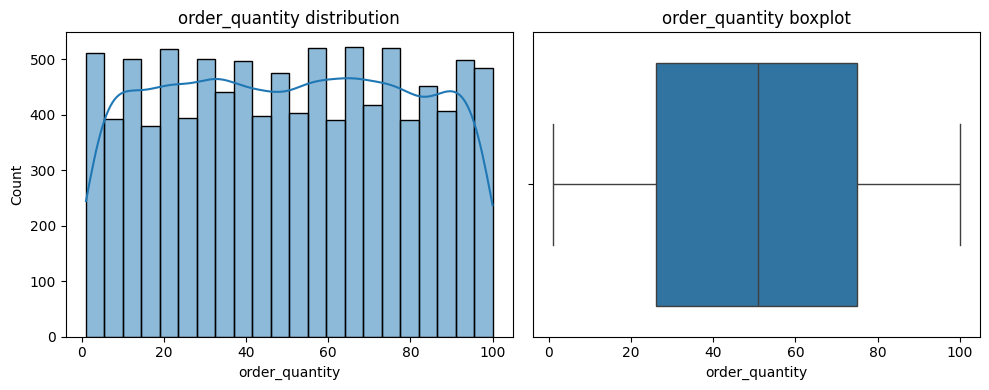

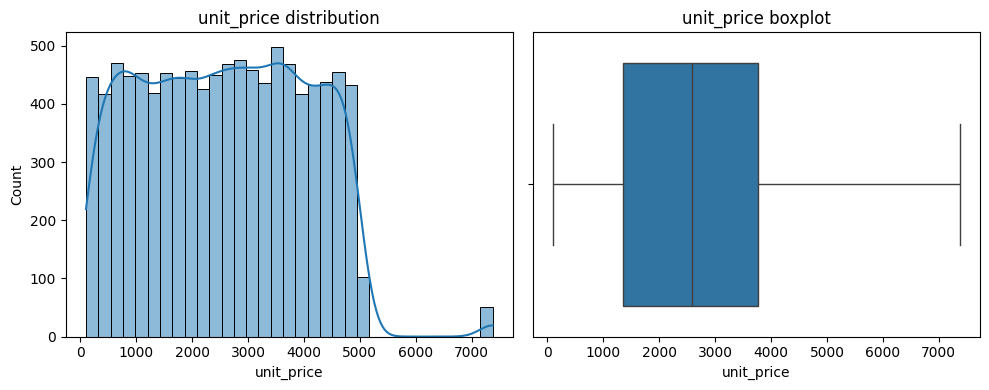

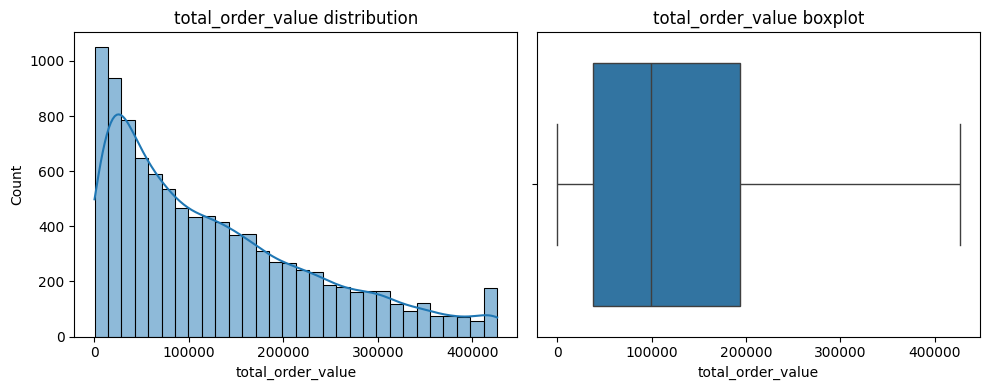

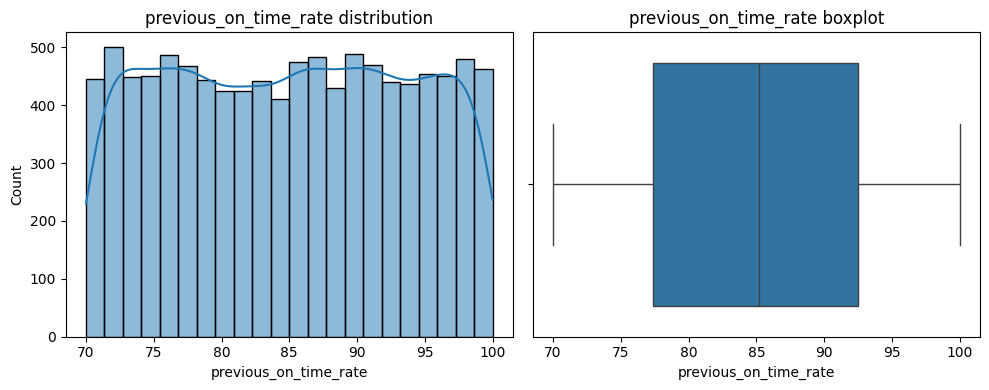

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df_clean  # for convenience

num_cols = ["supplier_rating", "supplier_lead_time",
            "shipping_distance_km", "order_quantity",
            "unit_price", "total_order_value",
            "previous_on_time_rate"]

for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f"{col} distribution")
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"{col} boxplot")
    plt.tight_layout()
    plt.show()


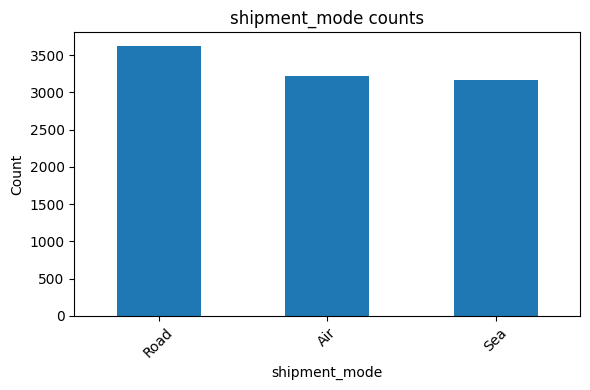

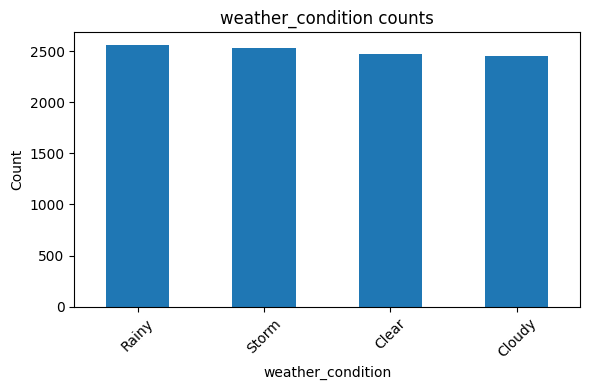

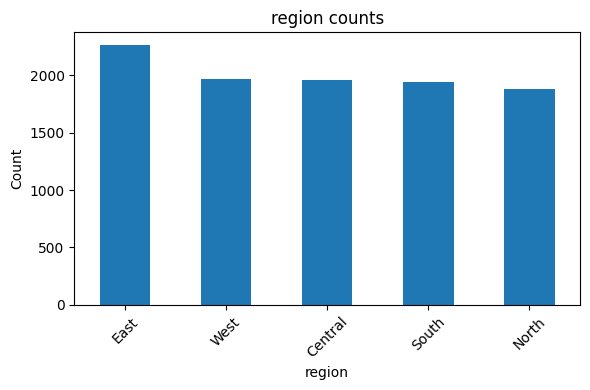

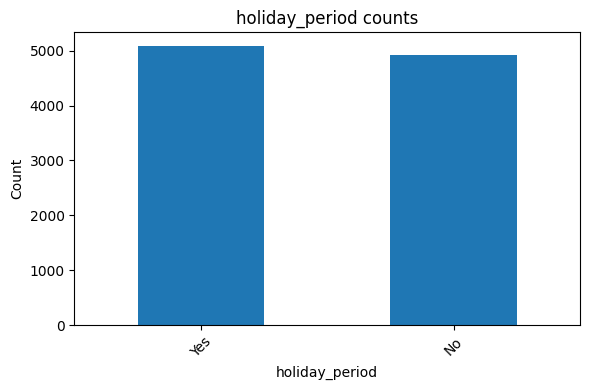

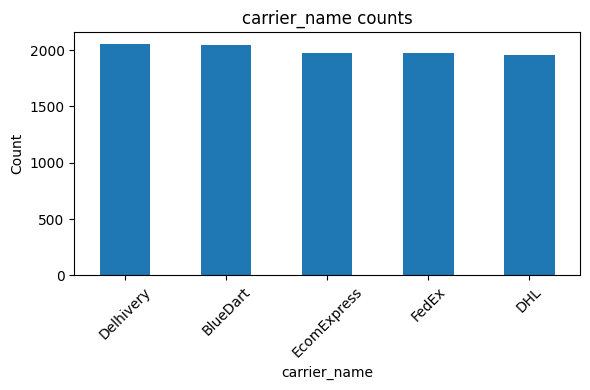

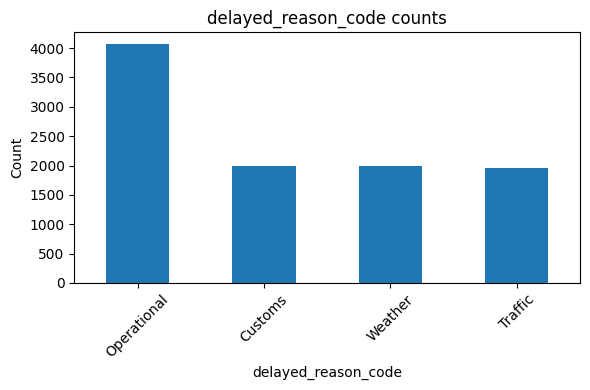

In [109]:
cat_cols = ["shipment_mode", "weather_condition",
            "region", "holiday_period",
            "carrier_name", "delayed_reason_code"]

for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind="bar")
    plt.title(f"{col} counts")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


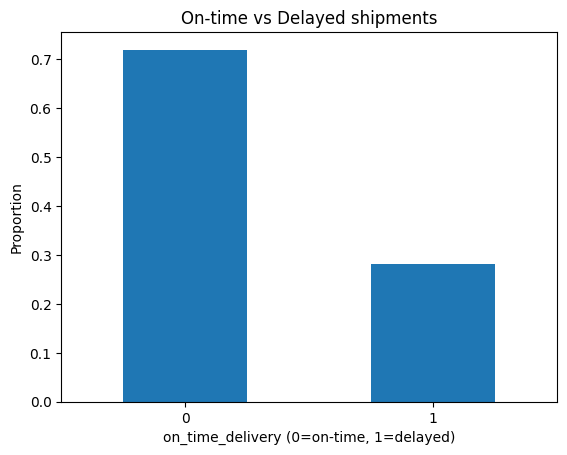

In [110]:
df["on_time_delivery"].value_counts(normalize=True).plot(kind="bar", rot=0)
plt.title("On-time vs Delayed shipments")
plt.xlabel("on_time_delivery (0=on-time, 1=delayed)")
plt.ylabel("Proportion")
plt.show()


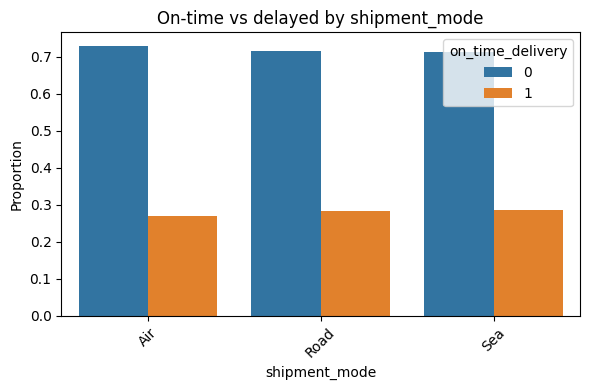

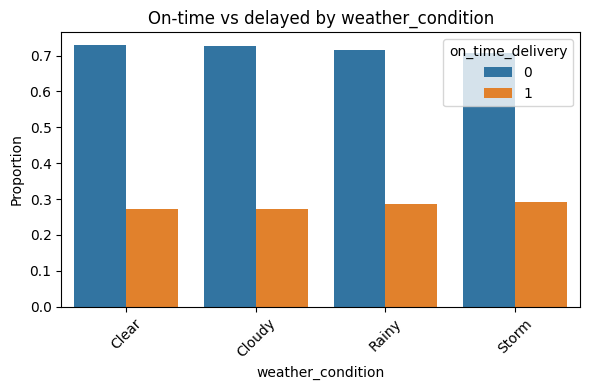

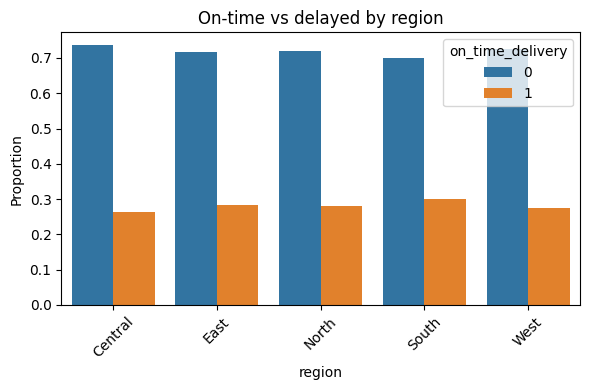

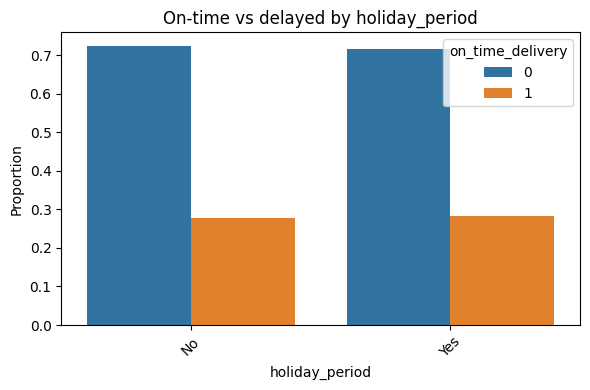

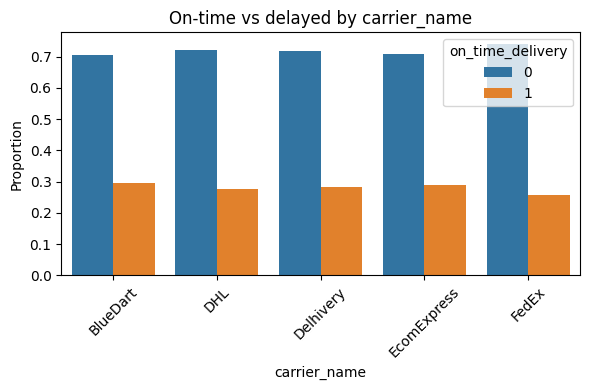

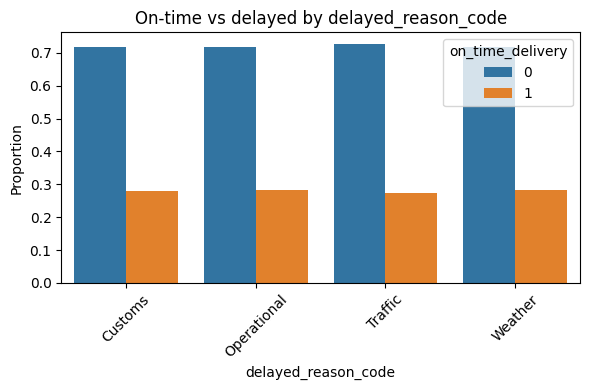

In [111]:
def target_rate_by_cat(col):
    temp = (df.groupby(col)["on_time_delivery"]
              .value_counts(normalize=True)
              .rename("prop")
              .reset_index())
    plt.figure(figsize=(6,4))
    sns.barplot(data=temp, x=col, y="prop", hue="on_time_delivery")
    plt.title(f"On-time vs delayed by {col}")
    plt.ylabel("Proportion")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

for col in cat_cols:
    target_rate_by_cat(col)


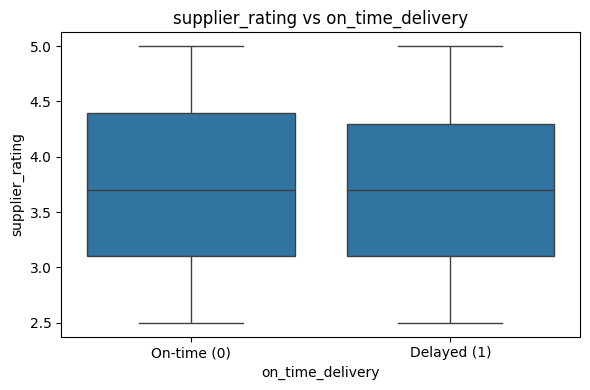

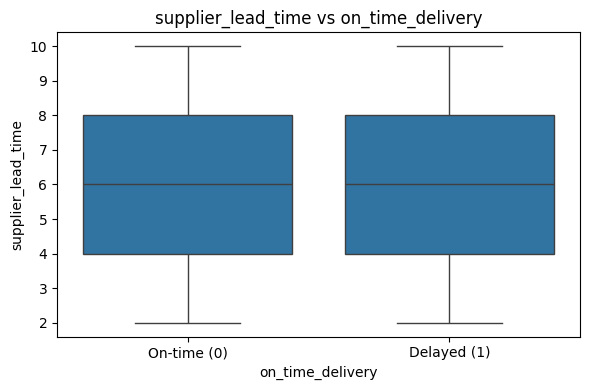

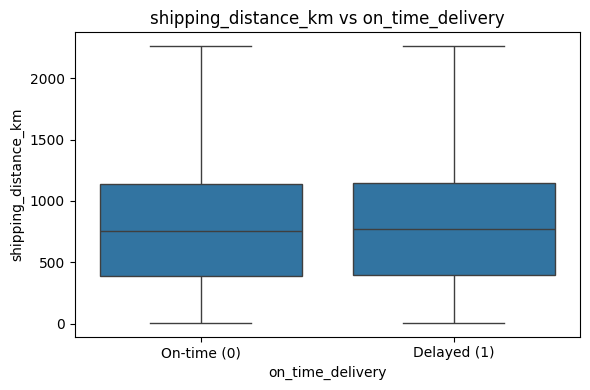

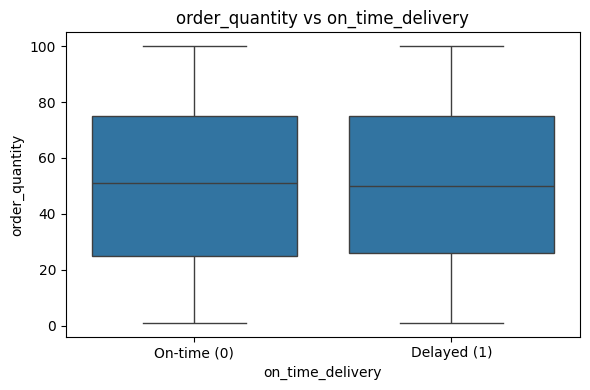

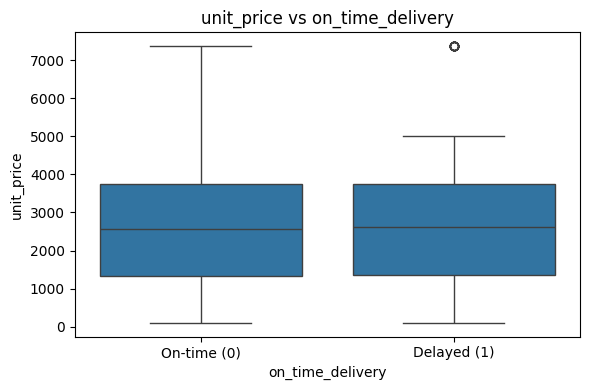

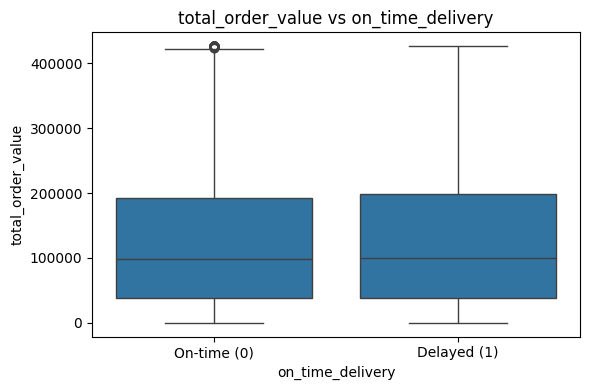

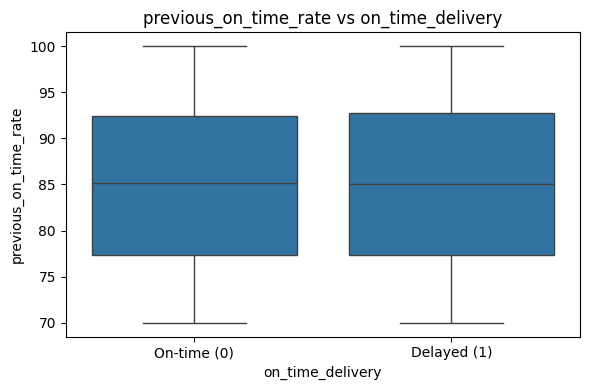

In [112]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="on_time_delivery", y=col)
    plt.title(f"{col} vs on_time_delivery")
    plt.xticks([0,1], ["On-time (0)", "Delayed (1)"])
    plt.tight_layout()
    plt.show()


In [113]:
df["order_month"] = df["order_date"].dt.month
df["order_dow"] = df["order_date"].dt.dayofweek
df["promised_lead_days"] = (df["promised_delivery_date"] - df["order_date"]).dt.days
df["actual_lead_days"] = (df["actual_delivery_date"] - df["order_date"]).dt.days
df["delay_days"] = (df["actual_delivery_date"] - df["promised_delivery_date"]).dt.days


In [114]:
df["order_month"] = df["order_date"].dt.month
df["order_dow"] = df["order_date"].dt.dayofweek
df["promised_lead_days"] = (df["promised_delivery_date"] - df["order_date"]).dt.days
df["actual_lead_days"] = (df["actual_delivery_date"] - df["order_date"]).dt.days
df["delay_days"] = (df["actual_delivery_date"] - df["promised_delivery_date"]).dt.days


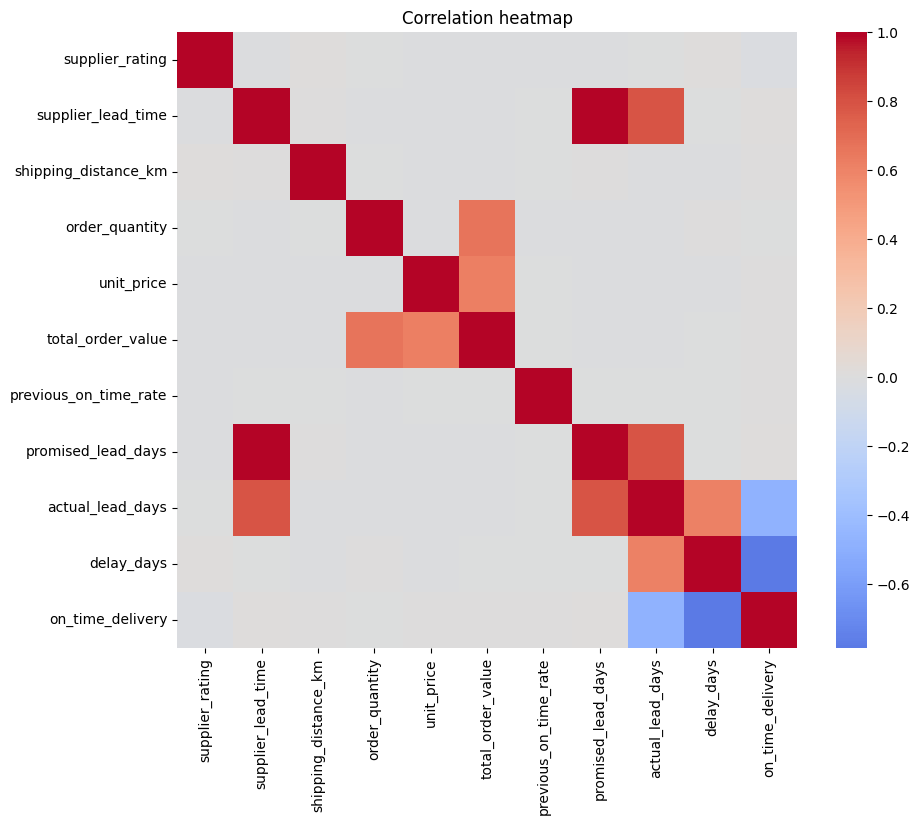

In [115]:
num_for_corr = num_cols + ["promised_lead_days",
                           "actual_lead_days", "delay_days",
                           "on_time_delivery"]

corr = df[num_for_corr].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()


In [ ]:
#MILESTONE 2

In [116]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_excel("shipment_dataset_10000_cleaned.xlsx")

df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10010 entries, 0 to 10009
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   order_id                10010 non-null  int64         
 1   supplier_id             10010 non-null  int64         
 2   supplier_rating         10010 non-null  float64       
 3   supplier_lead_time      10010 non-null  int64         
 4   order_date              10010 non-null  datetime64[ns]
 5   promised_delivery_date  10010 non-null  datetime64[ns]
 6   actual_delivery_date    10010 non-null  datetime64[ns]
 7   shipment_mode           10010 non-null  object        
 8   shipping_distance_km    10010 non-null  int64         
 9   order_quantity          10010 non-null  int64         
 10  unit_price              10010 non-null  float64       
 11  total_order_value       10010 non-null  float64       
 12  weather_condition       10010 non-null  object

order_id                  0
supplier_id               0
supplier_rating           0
supplier_lead_time        0
order_date                0
promised_delivery_date    0
actual_delivery_date      0
shipment_mode             0
shipping_distance_km      0
order_quantity            0
unit_price                0
total_order_value         0
weather_condition         0
region                    0
holiday_period            0
previous_on_time_rate     0
carrier_name              0
delayed_reason_code       0
on_time_delivery          0
dtype: int64

In [117]:
target_col = "on_time_delivery"
X = df.drop(columns=[target_col])
y = df[target_col]


In [118]:
X["order_month"] = df["order_date"].dt.month
X["order_dow"] = df["order_date"].dt.dayofweek

X["promised_lead_days"] = (df["promised_delivery_date"] - df["order_date"]).dt.days
X["actual_lead_days"] = (df["actual_delivery_date"] - df["order_date"]).dt.days
X["delay_days"] = (df["actual_delivery_date"] - df["promised_delivery_date"]).dt.days

# Example: cost-to-distance ratio
X["cost_per_km"] = df["total_order_value"] / (df["shipping_distance_km"] + 1)


In [119]:
date_cols = ["order_date", "promised_delivery_date", "actual_delivery_date"]
X = X.drop(columns=date_cols)

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_features, categorical_features


(['order_id',
  'supplier_id',
  'supplier_rating',
  'supplier_lead_time',
  'shipping_distance_km',
  'order_quantity',
  'unit_price',
  'total_order_value',
  'previous_on_time_rate',
  'promised_lead_days',
  'actual_lead_days',
  'delay_days',
  'cost_per_km'],
 ['shipment_mode',
  'weather_condition',
  'region',
  'holiday_period',
  'carrier_name',
  'delayed_reason_code'])

In [120]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [121]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape


((8008, 21), (2002, 21))